In [ ]:
!pip install -q insightface mtcnn opencv-python matplotlib scikit-learn
!pip install -q onnxruntime onnx onnxconverter-common
!pip install -q torch torchvision
!pip install -q tf2onnx tensorflow onnx-tf

In [ ]:
import cv2
import os
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import onnxruntime as ort
import onnx
from onnxconverter_common import float16
from google.colab import drive
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

In [ ]:
#drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Tu ruta actual (asegúrate de que coincida con tu Drive)
#DATASET_PATH = "/content/drive/MyDrive/Tesis VIU/BASE DE DATOS IMAGENES/BASE DE DATOS IMAGENES"
DATASET_PATH = "BASE_DE_DATOS_IMAGENES"

In [ ]:
import random
from sklearn.model_selection import train_test_split, KFold
import numpy as np

all_data = []
for person in os.listdir(DATASET_PATH):
    person_path = os.path.join(DATASET_PATH, person)
    if not os.path.isdir(person_path): continue
    for img_name in os.listdir(person_path):
        all_data.append((os.path.join(person_path, img_name), person))

print(f"Total de imágenes para el experimento: {len(all_data)}")

Total de imágenes para el experimento: 400


In [ ]:
from insightface.app import FaceAnalysis

# Volvemos a definir 'app'
app = FaceAnalysis(name="buffalo_s")
app.prepare(ctx_id=0, det_size=(640, 640))

def evaluate_model(train_set, test_set):
    """
    Función que recibe un set de entrenamiento y uno de prueba,
    genera los embeddings promedio y retorna la precisión.
    """
    db_embeddings = {}
    temp_storage = {}

    # 1. Crear la base de datos con las imágenes de ENTRENAMIENTO
    for path, name in train_set:
        img = cv2.imread(path)
        if img is None: continue
        faces = app.get(img)
        if faces:
            if name not in temp_storage: temp_storage[name] = []
            temp_storage[name].append(faces[0].embedding)

    # Promediar embeddings por persona
    for name, embs in temp_storage.items():
        db_embeddings[name] = np.mean(embs, axis=0)

    # 2. Validar con las imágenes de PRUEBA
    hits = 0
    total = 0
    for path, true_name in test_set:
        img = cv2.imread(path)
        if img is None: continue
        faces = app.get(img)
        if faces:
            emb_test = faces[0].embedding
            best_score = -1
            match_name = "Desconocido"

            # Comparar contra la base de datos generada
            for name, db_emb in db_embeddings.items():
                score = cosine_similarity(emb_test.reshape(1,-1), db_emb.reshape(1,-1))[0][0]
                if score > best_score:
                    best_score = score
                    match_name = name

            # Si el nombre coincide y supera el umbral, es un acierto
            if best_score > 0.45 and match_name == true_name:
                hits += 1
            total += 1

    accuracy = hits / total if total > 0 else 0
    return accuracy

download_path: /root/.insightface/models/buffalo_s


100%|██████████| 124617/124617 [00:02<00:00, 50773.65KB/s]
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_s/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_s/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_s/det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_s/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_s/w600k_mbf.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


In [ ]:
# --- EXPERIMENTOS DE PARTICIÓN ---
partitions = [0.3, 0.2, 0.1]
labels = ["70/30", "80/20", "90/10"]
final_results = {}

print("--- EVALUANDO PARTICIONES PORCENTUALES ---")
for i, test_size in enumerate(partitions):
    # Dividimos los datos
    train, test = train_test_split(all_data, test_size=test_size, stratify=[d[1] for d in all_data], random_state=42)

    # Evaluamos
    acc = evaluate_model(train, test)
    final_results[labels[i]] = acc
    print(f"Esquema {labels[i]}: Precisión Final = {acc:.2%}")

# --- EXPERIMENTO K-FOLD (K=5) ---
print("\n--- EVALUANDO K-FOLD CROSS VALIDATION (K=5) ---")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
data_np = np.array(all_data)

for fold, (train_idx, test_idx) in enumerate(kf.split(data_np)):
    train, test = data_np[train_idx], data_np[test_idx]
    acc = evaluate_model(train, test)
    fold_accuracies.append(acc)
    print(f"Fold {fold+1}: Precisión = {acc:.2%}")

print(f"\nResultado Promedio K-Fold: {np.mean(fold_accuracies):.2%}")
print(f"Desviación Estándar (Estabilidad): {np.std(fold_accuracies):.4f}")

--- EVALUANDO PARTICIONES PORCENTUALES ---
Esquema 70/30: Precisión Final = 98.33%
Esquema 80/20: Precisión Final = 97.50%
Esquema 90/10: Precisión Final = 97.50%

--- EVALUANDO K-FOLD CROSS VALIDATION (K=5) ---
Fold 1: Precisión = 98.75%
Fold 2: Precisión = 100.00%
Fold 3: Precisión = 100.00%
Fold 4: Precisión = 97.50%
Fold 5: Precisión = 97.50%

Resultado Promedio K-Fold: 98.75%
Desviación Estándar (Estabilidad): 0.0112


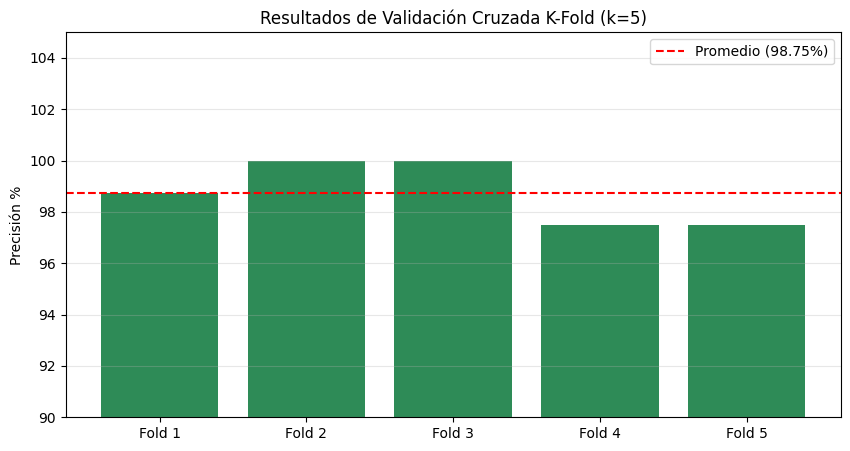

In [ ]:
import matplotlib.pyplot as plt

folds = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']
accuracies = [98.75, 100.0, 100.0, 97.50, 97.50]

plt.figure(figsize=(10, 5))
plt.bar(folds, accuracies, color='seagreen')
plt.axhline(y=98.75, color='r', linestyle='--', label='Promedio (98.75%)')
plt.ylim(90, 105)
plt.ylabel('Precisión %')
plt.title('Resultados de Validación Cruzada K-Fold (k=5)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
# EJECUTA ESTO PRIMERO
final_face_db = {}
temp_db = {}

# DATASET_PATH debe ser la carpeta donde están las carpetas de cada persona
for person in os.listdir(DATASET_PATH):
    person_path = os.path.join(DATASET_PATH, person)
    if not os.path.isdir(person_path): continue

    embs = []
    for img_name in os.listdir(person_path):
        img_p = os.path.join(person_path, img_name)
        img = cv2.imread(img_p)
        if img is None: continue
        res = app.get(img)
        if res:
            embs.append(res[0].embedding)

    if embs:
        final_face_db[person] = np.mean(embs, axis=0)

print("Base de datos actualizada. Personas cargadas:", list(final_face_db.keys()))

Base de datos actualizada. Personas cargadas: ['Estudiante_020', 'Estudiante_019', 'Estudiante_016', 'Estudiante_013', 'Estudiante_018', 'Estudiante_012', 'Estudiante_014', 'Estudiante_011', 'Estudiante_017', 'Estudiante_015', 'Estudiante_004', 'Estudiante_009', 'Estudiante_008', 'Estudiante_001', 'Estudiante_002', 'Estudiante_006', 'Estudiante_005', 'Estudiante_007', 'Estudiante_003', 'Estudiante_010']


In [ ]:
# EJECUTA ESTO DESPUÉS
img_bytes = take_photo()
with open("webcam.jpg", "wb") as f:
    f.write(img_bytes)

webcam_img = cv2.imread("webcam.jpg")
webcam_img = resize_image(webcam_img)
webcam_rgb = cv2.cvtColor(webcam_img, cv2.COLOR_BGR2RGB)
faces = app.get(webcam_rgb)

if len(faces) == 0:
    print("No se detectó ningún rostro. ¡Acércate más a la cámara!")
else:
    for face in faces:
        emb_webcam = face.embedding
        best_match = "Nadie"
        best_score = -1

        # 1. Comparación matemática
        for name, db_emb in final_face_db.items():
            score = cosine_similarity(emb_webcam.reshape(1,-1), db_emb.reshape(1,-1))[0][0]
            if score > best_score:
                best_score = score
                best_match = name

        # 2. LÓGICA DE VALIDACIÓN (Coloca esto aquí)
        # Un score de 0.15 es ruido. Subimos el umbral a 0.45 para la Tesis.
        umbral_tesis = 0.45

        if best_score >= umbral_tesis:
            label = f"{best_match} ({best_score:.2f})"
            color = (0, 255, 0) # Verde: Identificado
            print(f"IDENTIFICADO: {best_match} con score de {best_score:.4f}")
        else:
            label = "Desconocido"
            color = (0, 0, 255) # Rojo: No está en la base de datos
            print(f"AVISO: Sujeto no reconocido. Score máximo hallado: {best_score:.4f}")

        # 3. Dibujo de la caja y etiqueta
        box = face.bbox.astype(int)
        cv2.rectangle(webcam_img, (box[0], box[1]), (box[2], box[3]), color, 2)
        cv2.putText(webcam_img, label, (box[0], box[1] - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

# Mostrar el resultado final
plt.imshow(cv2.cvtColor(webcam_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

NameError: name 'take_photo' is not defined